## Import Libraries

In [129]:
import pandas as pd
from prophet import Prophet
import numpy as np

## Import Scikit-Learn Utilities

In [130]:
from sklearn.model_selection import train_test_split

## Load Dataset

In [131]:
df = pd.read_csv('/content/listings.csv')

## Inspect Column Names

In [132]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

## Extract Date Series

In [133]:
ds = df['price_quote_checkin_date']

## Preview Date Series

In [134]:
ds

,price_quote_checkin_date
0,2026-07-16
1,2026-06-29
2,2026-07-19
3,2026-07-12
4,2026-06-29
...,...
1487,2026-08-14
1488,2026-07-13
1489,2026-07-19
1490,2026-06-29


## Convert Column to Datetime Objects

In [135]:
df['price_quote_checkin_date'] = pd.to_datetime(df['price_quote_checkin_date'])

## Extract Target Variable

In [136]:
y = df['price_quote_price_per_night']

## Preview Target Variable

In [137]:
y

,price_quote_price_per_night
0,178.80
1,142.75
2,153.70
3,58.50
4,218.20
...,...
1487,152.67
1488,243.00
1489,148.92
1490,239.65


## Subset Data for Modeling

In [138]:
df2 = df.copy()
df2 = df2[['price_quote_checkin_date', 'price_quote_price_per_night', 'bathrooms', 'beds']]

## Inspect Subsetted Dataframe

In [139]:
df2

,price_quote_checkin_date,price_quote_price_per_night,bathrooms,beds
0,2026-07-16,178.80,1.5,1.0
1,2026-06-29,142.75,1.0,1.0
2,2026-07-19,153.70,NaN,NaN
3,2026-07-12,58.50,1.5,2.0
4,2026-06-29,218.20,1.0,1.0
...,...,...,...,...
1487,2026-08-14,152.67,1.0,2.0
1488,2026-07-13,243.00,1.0,4.0
1489,2026-07-19,148.92,1.0,2.0
1490,2026-06-29,239.65,1.0,1.0


## Check for Missing Values

In [140]:
df2.isna().sum()

,0
price_quote_checkin_date,328
price_quote_price_per_night,353
bathrooms,530
beds,432


## Remove Rows with Null Values

In [141]:
df2 = df2.dropna()

## Rename Columns for Prophet Compliance

In [142]:
df2 = df2.rename(columns={'price_quote_checkin_date': 'ds', 'price_quote_price_per_night': 'y'})

## Inspect Renamed Dataframe

In [143]:
df2

,ds,y,bathrooms,beds
0,2026-07-16,178.80,1.5,1.0
1,2026-06-29,142.75,1.0,1.0
3,2026-07-12,58.50,1.5,2.0
4,2026-06-29,218.20,1.0,1.0
5,2026-06-29,242.20,1.0,1.0
...,...,...,...,...
1487,2026-08-14,152.67,1.0,2.0
1488,2026-07-13,243.00,1.0,4.0
1489,2026-07-19,148.92,1.0,2.0
1490,2026-06-29,239.65,1.0,1.0


## Verify Column Names

In [144]:
df2.columns

Index(['ds', 'y', 'bathrooms', 'beds'], dtype='object')

## Initialize and Fit Prophet Model

In [145]:
m = Prophet()
m.add_regressor('beds')
m.add_regressor('bathrooms')
m.fit(df2)
    #m.add_regressor(column)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


## Create Future Timeframe Dataframe

In [146]:
future_df = m.make_future_dataframe(periods=365)

## Preview Future Dataframe Structure

In [147]:
future_df

,ds
0,2026-06-28
1,2026-06-29
2,2026-06-30
3,2026-07-01
4,2026-07-02
...,...
490,2028-06-10
491,2028-06-11
492,2028-06-12
493,2028-06-13


## Map Historical 'Beds' Average to Future Dates

In [148]:
# 1. Calculate historical average by month from master data
monthly_averages = df2.groupby(df2['ds'].dt.month)['beds'].mean()

# 2. Map those historical monthly averages directly onto the future dates
future_df['beds'] = future_df['ds'].dt.month.map(monthly_averages)



## Map Historical 'Bathrooms' Average to Future Dates

In [149]:
# 1. Calculate historical average by month from master data
monthly_averages = df2.groupby(df2['ds'].dt.month)['bathrooms'].mean()

# 2. Map those historical monthly averages directly onto the future dates
future_df['bathrooms'] = future_df['ds'].dt.month.map(monthly_averages)

## Inspect Predicted 'Beds' values

In [150]:
future_df['beds']

,beds
0,1.962025
1,1.962025
2,1.962025
3,2.595420
4,2.595420
...,...
490,1.962025
491,1.962025
492,1.962025
493,1.962025


## Inspect Predicted 'Bathrooms' values

In [151]:
future_df['bathrooms']

,bathrooms
0,1.238397
1,1.238397
2,1.238397
3,1.424936
4,1.424936
...,...
490,1.238397
491,1.238397
492,1.238397
493,1.238397


## Round Future Regressors to Integers

In [152]:
import numpy as np

# Apply ceiling directly to your regressor or target column
future_df['beds'] = np.ceil(future_df['beds'])
future_df['bathrooms'] = np.floor(future_df['bathrooms'])


## Inspect Final Future Dataframe

In [153]:
future_df

,ds,beds,bathrooms
0,2026-06-28,2.0,1.0
1,2026-06-29,2.0,1.0
2,2026-06-30,2.0,1.0
3,2026-07-01,3.0,1.0
4,2026-07-02,3.0,1.0
...,...,...,...
490,2028-06-10,2.0,1.0
491,2028-06-11,2.0,1.0
492,2028-06-12,2.0,1.0
493,2028-06-13,2.0,1.0


## Generate Forecast

In [154]:
forecast = m.predict(future_df)

## Plot Forecast Results

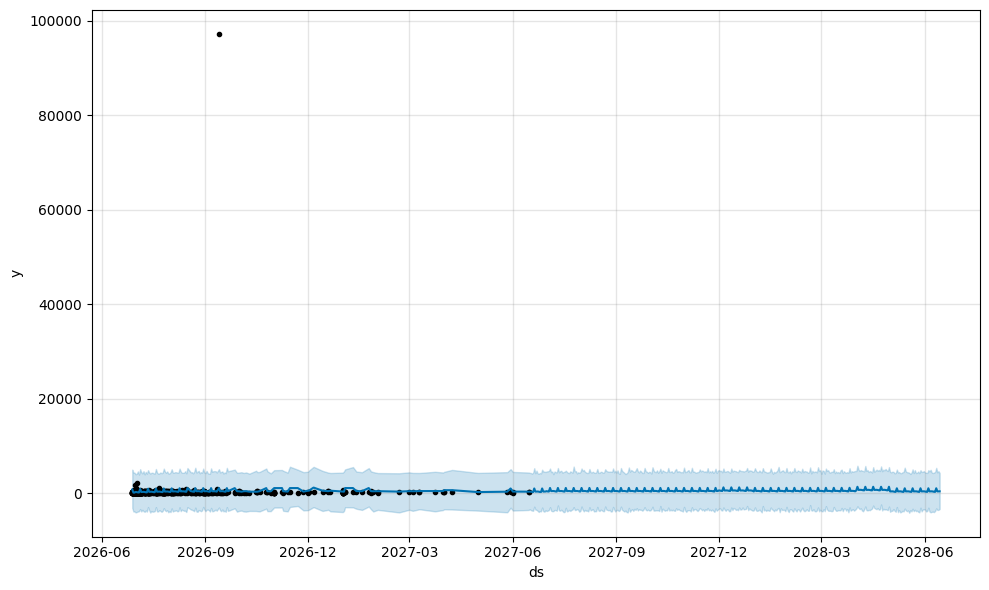

In [155]:
fig1 = m.plot(forecast)

## Create Second Data Subset

In [156]:
df3 = df.copy()
df3 = df3[['price_quote_checkin_date', 'price_quote_price_per_night','bedrooms','accommodates']]

## Preview Second Data Subset

In [157]:
df3

,price_quote_checkin_date,price_quote_price_per_night,bedrooms,accommodates
0,2026-07-16,178.80,1.0,2
1,2026-06-29,142.75,NaN,2
2,2026-07-19,153.70,1.0,2
3,2026-07-12,58.50,NaN,2
4,2026-06-29,218.20,1.0,2
...,...,...,...,...
1487,2026-08-14,152.67,1.0,4
1488,2026-07-13,243.00,2.0,4
1489,2026-07-19,148.92,1.0,2
1490,2026-06-29,239.65,1.0,2


## Clean Missing Data in Second Subset

In [158]:
df3 = df3.dropna()

## Verify No Missing Values

In [159]:
df3.isna().sum()

,0
price_quote_checkin_date,0
price_quote_price_per_night,0
bedrooms,0
accommodates,0


## Rename Columns for Second Model

In [160]:
df3 = df3.rename(columns={'price_quote_checkin_date': 'ds', 'price_quote_price_per_night': 'y'})

## Inspect Cleaned Second Dataframe

In [161]:
df3

,ds,y,bedrooms,accommodates
0,2026-07-16,178.80,1.0,2
2,2026-07-19,153.70,1.0,2
4,2026-06-29,218.20,1.0,2
5,2026-06-29,242.20,1.0,2
6,2026-06-29,212.00,1.0,2
...,...,...,...,...
1487,2026-08-14,152.67,1.0,4
1488,2026-07-13,243.00,2.0,4
1489,2026-07-19,148.92,1.0,2
1490,2026-06-29,239.65,1.0,2


## Verify Second Dataframe Columns

In [162]:
df3.columns

Index(['ds', 'y', 'bedrooms', 'accommodates'], dtype='object')

## Fit Second Prophet Model with Bedrooms/Accommodates

In [163]:
m = Prophet()
m.add_regressor('bedrooms')
m.add_regressor('accommodates')
m.fit(df3)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


## Create Future Dataframe (FS)

In [174]:
FS = m.make_future_dataframe(periods=365)

## Preview FS Structure

In [175]:
FS

,ds
0,2026-06-28
1,2026-06-29
2,2026-06-30
3,2026-07-01
4,2026-07-02
...,...
499,2028-06-10
500,2028-06-11
501,2028-06-12
502,2028-06-13


## Calculate and Map Monthly 'Bedrooms' Averages

In [166]:
# 1. Calculate historical average by month from master data
monthly_averages = df3.groupby(df3['ds'].dt.month)['bedrooms'].mean()

# 2. Map those historical monthly averages directly onto the future dates
FS['bedrooms'] = FS['ds'].dt.month.map(monthly_averages)

## Inspect FS with Bedrooms

In [167]:
FS

,ds,bedrooms
0,2026-06-28,1.502075
1,2026-06-29,1.502075
2,2026-06-30,1.502075
3,2026-07-01,2.082192
4,2026-07-02,2.082192
...,...,...
499,2028-06-10,1.502075
500,2028-06-11,1.502075
501,2028-06-12,1.502075
502,2028-06-13,1.502075


## Calculate and Map Monthly 'Accommodates' Averages

In [168]:
# 1. Calculate historical average by month from master data
monthly_averages = df3.groupby(df3['ds'].dt.month)['accommodates'].mean()

# 2. Map those historical monthly averages directly onto the future dates
FS['accommodates'] = FS['ds'].dt.month.map(monthly_averages)

## Inspect FS 'Accommodates' column

In [169]:
FS['accommodates']

,accommodates
0,3.336100
1,3.336100
2,3.336100
3,4.057078
4,4.057078
...,...
499,3.336100
500,3.336100
501,3.336100
502,3.336100


## Apply Flooring to FS Regressors

In [170]:
import numpy as np

FS['accommodates'] = np.floor(FS['accommodates'])
FS['bedrooms'] = np.floor(FS['bedrooms'])

## Final Inspection of FS

In [171]:
FS

,ds,bedrooms,accommodates
0,2026-06-28,1.0,3.0
1,2026-06-29,1.0,3.0
2,2026-06-30,1.0,3.0
3,2026-07-01,2.0,4.0
4,2026-07-02,2.0,4.0
...,...,...,...
499,2028-06-10,1.0,3.0
500,2028-06-11,1.0,3.0
501,2028-06-12,1.0,3.0
502,2028-06-13,1.0,3.0


## Execute Second Forecast

In [172]:
forecast2 = m.predict(FS)

## Plot Second Forecast Results

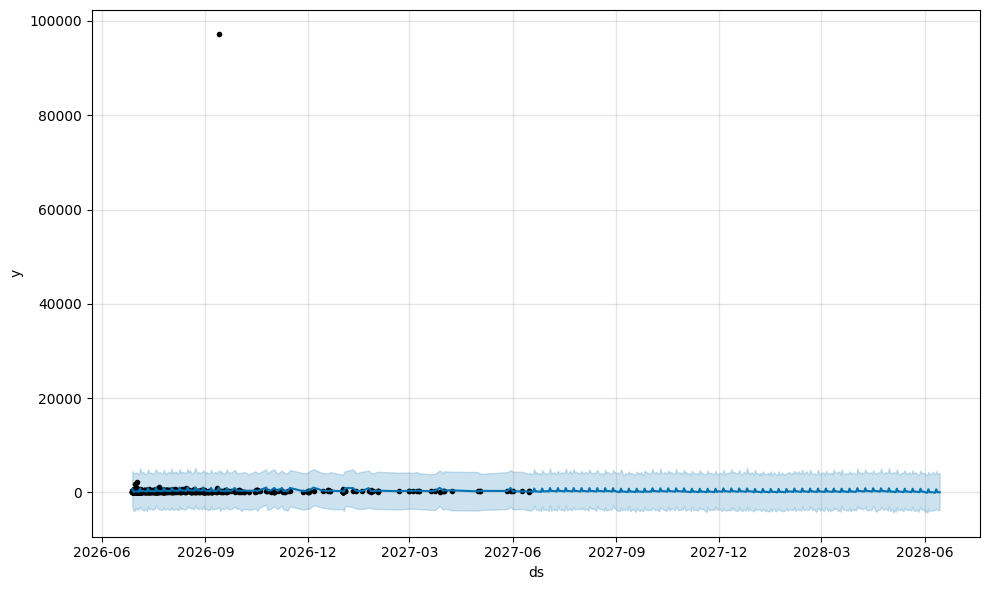

In [173]:
fig2 = m.plot(forecast2)

## Plot Forecast Components

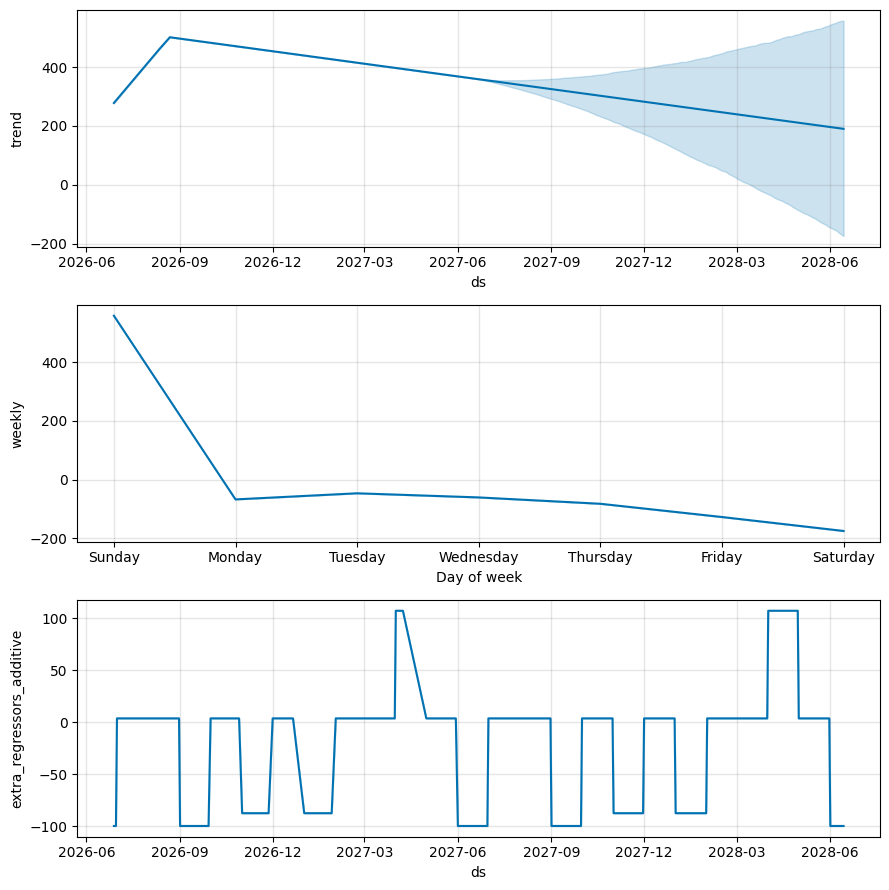

In [177]:
fig2 = m.plot_components(forecast2)